# Le' Sean Roberts 

# CUNY City Tech Alumni (Graduate)

# Exploratory Development with UNICEF MICS

[Email](lesean.roberts85@gmail.com)

[LinkedIn](https://www.linkedin.com/in/le-sean-roberts)

[GitHub](https://github.com/LeSeanRoberts)

## Abstract

This development involves the application of Multiple Indicator Cluster Surveys (MICS) from the United Nations International Children's Emergency Fund (UNICEF). Surveys are among the world's largest and premier household survey programmes, specifically designed to collect statistically sound and internationally comparable data on the well-being of children and women. Often the comprehension and assimilation of data for such types of surveys towards data science interests can be challenging due to lack of routine exposure to the general public in daily life. This development involves premature exploratory tasks.  

## Introduction

Since its inception in 1995, UNICEF's MICS has evolved into a primary data source for monitoring the Sustainable Development Goals (SDGs), covering approximately 40% of household-based SDG indicators. Such has become the monumental source of statistically sound and internationally comparable data on children and women worldwide. MICS is an integral part of the plans and policies of many governments around the world.

MICS data is collected through face-to-face interviews using a modular questionnaire design. This allows countries to customize the survey to their specific needs while maintaining global comparability.

The standard set includes five main questionnaires:

1. Household Questionnaire: Focuses on living conditions, household members, education, and water/sanitation (WASH).

2. Women’s Questionnaire (ages 15–49): Covers fertility, maternal health, contraception, and attitudes toward domestic violence.

3. Men’s Questionnaire (ages 15–49): Often a subset of households, focusing on health, HIV/AIDS knowledge, and mass media use.

4. Children Under Five: Answered by mothers/caregivers; includes nutrition, immunization, and early childhood development.

5. Children & Adolescents (ages 5–17): Focuses on child labour, child functioning (disability), and foundational learning skills.

MICS is quite useful in data science—especially in the following fields:

1. Development economics

2. Public health

3. Climatology + socio-economic analysis (relevant to your work)

4. Policy modelling

5. Survey statistics / causal inference

Taken up is the challenge of comprehending and assimilating such data to develop exploratory models and analyses as a beginner step for future advanced interests. As a test case, applied is the Trinidad and Tobago MICS 2022 data. Will pursue stochastic, statistical and machine learning development. 

## Data Format and Structure

UNICEF MICS data is published in the form of .sav files. It is the native data format of IBM SPSS Statistics. It’s widely used by organisations like UNICEF for datasets. MICS datasets are complex survey datasets that include:

1. Variable labels (human-readable names)

2. Value labels (e.g., 1 = Male, 2 = Female)

3. Survey weights

4. Sampling design info (strata, clusters)

The .sav format preserves all of that metadata cleanly—much better than CSV or general spreadsheet orientation.

Data files are only available in SPSS format can be opened/converted by most recent versions of other statistical software.

The files involving Trinidad and Tobago MICS 2022 and other foreign places are genegeral six in total. Such are

1. hh.sav

       Households - including Water Quality Testing Questionnaire
2. hl.sav

       Household members

3. wm.sav

       Women (age 15-49 years)

4. bh.sav 

       Fertility/Birth history module (administered to women age 15-49 years)

5. ch.sav

       Children under five

6. fs.sav

       Children age 5-17 years

For more information on survey and sampling methodology such can found on the UNICEF MICS  general website. The standard data dictionary and standard SPSS syntax files for creation of background variables and tabulations of the Survey Findings Report are available at mics.unicef.org/tools. Survey datasets are made publicly available on behalf of the Central Statistical Office of Trinidad and Tobago.


The bh.sav dataset contains one row per child ever born to interviewed women (usually age 15–49). So instead of household-level or individual-level data, this is event-level (child-level) data.

The bh.sav file **SHOULD NOT** be treated like a flat dataset.

1. It is Hierarchical

2. Needs merging with women (wm.sav) and household (hh.sav)

**BH Identification Variables (linking keys)** - these connect to other datasets like household or women files:

HH1 → Cluster number

HH2 → Household number

LN → Line number of the woman (mother)

Such above variables permit merger with the Household file (hh.sav) and the Women file (wm.sav). 

**Century Month Code (CMC)**

Dates in MICS are often stored as CMC. Example:

    January 2000 = 1201

    Used for: Age calculations and Time-to-event models

## Data Assimilation

Assimilating and inspecting the files (of interest):

In [1]:
# Loading the basic libraries
import numpy as np
import pandas as pd
import pyreadstat

fertility_birth_story_df, bh_meta = pyreadstat.read_sav("bh.sav") # birth history
women_df, wm_meta = pyreadstat.read_sav("wm.sav")  # women
household_df, hh_meta = pyreadstat.read_sav("hh.sav")  # household

Inspecting the fertility and birth history data:

In [2]:
fertility_birth_story_df.info() # variable names
bh_meta.column_labels # human-readable labels

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8267 entries, 0 to 8266
Data columns (total 49 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   HH1        8267 non-null   float64
 1   HH2        8267 non-null   float64
 2   LN         8267 non-null   float64
 3   WM1        8267 non-null   float64
 4   WM2        8267 non-null   float64
 5   WM3        8267 non-null   float64
 6   WMINT      8267 non-null   float64
 7   BH0        8267 non-null   float64
 8   BH2        8267 non-null   float64
 9   BH3        8267 non-null   float64
 10  BH4D       8267 non-null   float64
 11  BH4M       8267 non-null   float64
 12  BH4Y       8267 non-null   float64
 13  BH5        8267 non-null   float64
 14  BH6        8077 non-null   float64
 15  BH7        8077 non-null   float64
 16  BH8        8077 non-null   float64
 17  BH9U       190 non-null    float64
 18  BH9N       190 non-null    float64
 19  BH10       8267 non-null   float64
 20  BH4C    

['Cluster number',
 'Household number',
 'Line number',
 'Cluster number',
 'Household number',
 "Woman's line number",
 'Interviewer number',
 'Line Number',
 'Twins',
 'Sex of child',
 'Day of birth',
 'Month of birth',
 'Year of birth',
 'Still alive',
 'Age of child',
 'Living with respondent',
 'Line number of child in HH',
 'Age at death (units)',
 'Age at death (number)',
 'Any other between births',
 'Date of birth of child (CMC)',
 'Date flag for BH4C',
 'Age at death months (imputed)',
 'Date flag for BH9C',
 'Presence of child U5 in HH during listing',
 'Supervisor number',
 'Area',
 'Region',
 'Date of interview women (CMC)',
 'Date of birth of woman (CMC)',
 'Birth history line number',
 'Ethnicity of household head',
 'Education',
 'Health insurance',
 'Birth order',
 "Mother's age at birth",
 'Previous birth interval',
 "Woman's sample weight",
 'Combined wealth score',
 'Wealth index quintile',
 'Wealth index decile',
 'Urban wealth score',
 'Urban wealth index quintile

In [3]:
print(fertility_birth_story_df.head(4)) # Showing first 4 rows fr each column

   HH1  HH2   LN  WM1  WM2  WM3  WMINT  BH0  BH2  BH3  ...  windex5  windex10  \
0  1.0  2.0  2.0  1.0  2.0  2.0   45.0  1.0  1.0  1.0  ...      3.0       6.0   
1  1.0  2.0  2.0  1.0  2.0  2.0   45.0  2.0  1.0  2.0  ...      3.0       6.0   
2  1.0  2.0  3.0  1.0  2.0  3.0   45.0  1.0  1.0  1.0  ...      3.0       6.0   
3  1.0  6.0  2.0  1.0  6.0  2.0   45.0  1.0  1.0  2.0  ...      2.0       3.0   

    wscoreu  windex5u  windex10u  wscorer  windex5r  windex10r  stratum  psu  
0  0.319969       3.0        6.0      NaN       NaN        NaN     11.0  1.0  
1  0.319969       3.0        6.0      NaN       NaN        NaN     11.0  1.0  
2  0.319969       3.0        6.0      NaN       NaN        NaN     11.0  1.0  
3 -0.441669       1.0        2.0      NaN       NaN        NaN     11.0  1.0  

[4 rows x 49 columns]


Inspecting the women data:

In [4]:
women_df.info() # variable names

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5895 entries, 0 to 5894
Columns: 390 entries, HH1 to psu
dtypes: float64(278), object(112)
memory usage: 17.5+ MB


In [5]:
wm_meta.column_labels # human-readable labels

['Cluster number',
 'Household number',
 'Line number',
 'Cluster number',
 'Household number',
 "Woman's line number",
 'Interviewer number',
 'Supervisor number',
 'Interviewer number',
 'Day of interview',
 'Month of interview',
 'Year of interview',
 'Respondent to another questionnaire',
 'Consent',
 "Consent for Woman's MICS Plus",
 'Personal or Communal Phone number',
 "Result of woman's interview",
 'Start of interview - Hour',
 'Start of interview - Minutes',
 'End of interview - Hour',
 'End of interview - Minutes',
 'Interview completed in private',
 'Language of the Questionnaire',
 'Language of the Interview',
 'Native language of the Respondent',
 'Translator used',
 'Household interviewer',
 'Finish',
 'Date of interview women (CMC)',
 'Month of birth of woman',
 'Year of birth of woman',
 'Age of woman',
 'Ever attended school',
 'Highest level of school attended',
 'Highest year attended at that level',
 'Ever completed that year',
 'Attended school during 2020 / 2021 

Inspecting the household data:

In [6]:
household_df.info() # variable names

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8969 entries, 0 to 8968
Columns: 306 entries, HH1 to psu
dtypes: float64(249), object(57)
memory usage: 20.9+ MB


In [7]:
hh_meta.column_labels # human-readable labels

['Cluster number',
 'Household number',
 'Interviewer number',
 'Supervisor number',
 'Day of interview',
 'Month of interview',
 'Year of interview',
 'Area',
 'Region',
 'HH selected for Questionnaire for Men',
 'HH selected for Water Quality Testing',
 'HH selected for Blank Testing',
 'Start of interview - Hour',
 'Start of interview - Minutes',
 'Consent',
 'End of interview - Hour',
 'End of interview - Minutes',
 'Language of the Questionnaire',
 'Language of the Interview',
 'Native language of the Respondent',
 'Translator used',
 'Rank number of the selected child',
 'Child line number',
 "Child's age",
 'Roster to check the consent for interview girls 15-17',
 'Roster to check the consent for interview girls 15-17',
 'Roster to check the consent for interview girls 15-17',
 'Roster to check the consent for interview girls 15-17',
 'Roster to check the consent for interview girls 15-17',
 'Roster to check the consent for interview girls 15-17',
 'Roster to check the consent f

## Data Dictionary

### Part 1 — Commonly Underestimated Issues in MICS Data

#### 1. Complex Survey Design (CRITICAL)

MICS is not simple random sampling. It uses:

* Stratification (stratum)
* Clustering (psu)
* Sampling weights (wmweight, hhweight)

Implication:

* Standard ML/regression without adjustment → biased estimates
* Variance underestimated if clustering ignored

---

#### 2. Unit of Analysis Confusion

You have multiple levels:

* Household (hh.sav)
* Woman (wm.sav)
* Child/Birth (bh.sav)

Your bh dataset is:
→ One row per child ever born

Implication:

* Duplicates at household level are expected
* Merging incorrectly can inflate observations

---

#### 3. Categorical Variables Disguised as Numeric

Most variables are coded numerically:

* 1 = Yes
* 2 = No
* 9 = Missing / DK

Implication:

* Treating as numeric breaks models
* Must decode using metadata

---

#### 4. Missing Data Is NOT Random

Common patterns:

* Structural missing (e.g., age at death only if dead)
* Survey skip logic

Example:

* BH6, BH7 only for dead children

Implication:

* Cannot use naive imputation
* Must respect survey logic

---

#### 5. Century Month Code (CMC)

Dates stored as integers

Implication:

* Must convert before time analysis
* Errors here → wrong survival times

---

#### 6. Duplicate Labels / Repeated Columns

You saw repeated labels like:

* "Roster to check consent..."

Implication:

* Variable names matter more than labels
* Labels are not unique

---

#### 7. Weight Scaling

Weights are large integers

Correct usage:
wmweight / 1,000,000

---

#### 8. Subsample Variables

Urban/rural wealth variables:

* wscoreu, wscorer

Implication:

* Missing values are expected
* Do NOT treat as random missing

---

#### 9. Survival Bias

Birth history includes only:

* Women alive at survey

Implication:

* Underestimates mortality in some contexts

---

#### 10. Time Alignment Issues

You are mixing:

* Child birth year
* Survey year
* Household conditions at survey

Implication:

* Risk of reverse causality

---

### Part 2 — Data Dictionary (bh.sav example) for Significant Variables

| Variable  | Description                               |
| --------- | ----------------------------------------- |
| HH1       | Cluster number                            |
| HH2       | Household number                          |
| LN        | Line number                               |
| WM1       | Cluster number                            |
| WM2       | Household number                          |
| WM3       | Woman's line number                       |
| WMINT     | Interviewer number                        |
| BH0       | Line Number: Sequential identifier for the child in the woman's birth history.                               |
| BH2       | Twins: Indicates if the birth was part of a multiple pregnancy (e.g., twins, triplets).                                    |
| BH3       | Sex of child                              |
| BH4D      | Day of birth                              |
| BH4M      | Month of birth                            |
| BH4Y      | Year of birth                             |
| BH5       | Still alive: Binary variable indicating if the child was alive at the time of the interview.                               |
| BH6       | Age of child: Current age of the child (if alive)                              |
| BH7       | Living with respondent: Indicates if the child resides in the same house as the mother.                    |
| BH8       | Line number of child in HH: The child’s unique ID in the household roster (if they live there).               |
| BH9U      | Age at death (units)                      |
| BH9N      | Age at death (number)                     |
| BH10      | Any other between births: A check variable to ensure no other births were missed between recorded events.                  |
| BH4C      | Date of birth of child (CMC)              |
| BH4F      | Date flag for BH4C: Indicates if the birth date was provided exactly or imputed.                        |
| BH9C      | Age at death months (imputed): Estimated age at death in months, used for calculating infant and under-five mortality rates.             |
| BH9F      | Date flag for BH9C: Indicates the level of precision/imputation for the age at death.                        |
| ListCat   | Presence of child U5 in HH during listing |
| HH4       | Supervisor number                         |
| HH6       | Area: Geographic location (e.g., Urban/Rural and the specific province or state).                                      |
| HH7       | Region: Geographic location (e.g., Urban/Rural and the specific province or state).                                    |
| WDOI      | Date of interview women (CMC)             |
| WDOB      | Date of birth of woman (CMC)              |
| BHLN      | Birth history line number                 |
| ethnicity | Ethnicity of household head: Cultural or ethnic group belonging.               |
| welevel   | Education: (none, primary, secondary, etc.).                                 |
| insurance | Health insurance: Whether the woman/household is covered by health insurance.                          |
| brthord   | Birth order: The numerical order of this child among all the woman's births (1st, 2nd, 3rd, etc.).                               |
| magebrt   | Mother's age at birth: How old the mother was when this specific child was born.                   |
| birthint  | Previous birth interval: The time elapsed (in months) between this birth and the one immediately preceding it.                   |
| wmweight  | Woman's sample weight                     |
| wscore    | Combined wealth score: A continuous value representing the household's relative wealth.                    |
| windex5   | Wealth index quintile: Households ranked into 5 equal groups (from poorest to richest).                     |
| windex10  | Wealth index decile: Households ranked into 10 equal groups (from poorest to richest).                       |
| wscoreu   | Urban wealth score                        |
| windex5u  | Urban wealth index quintile               |
| windex10u | Urban wealth index decile                 |
| wscorer   | Rural wealth score                        |
| windex5r  | Rural wealth index quintile               |
| windex10r | Rural wealth index decile                 |
| stratum   | Sample strata                             |
| psu       | Primary sampling unit                     |


## Basic Preliminary Data Wrangling For a Survival Analysis Structure

For BH9U (Age at death (unit)) and BH9N (Age at death (number)) the counts of non-missing data is too high compared to the other variables for any type of imputing to be meaningful. As well, such two variables are too socioeconomic and sociopolitically sensitive issues to crudely apply imputing schemes. 

Starting with a quick diagnostic:

**Identifying "Pseudo-Missing" Values**

Developing a missing code list that defines specific numbers that are standard placeholders in survey research.

Common placeholders for unknowns:

1. 8 / 98 / 998: Usually represent "Don't Know."

2. 9 / 99 / 999: Usually represent "Missing" or "Refused to answer."

3. The variation (9 vs 99 vs 999) depends on the "width" of the column (e.g., if a child's age is 2 digits, 99 is used).

The "Inconsistent" & "Other" Codes:

1. 7 (or 97, 997): Inconsistent. This is used when the respondent provided an answer that contradicts another part of the survey (e.g., saying a child is 5 years old but was born only 2 years ago).

2. 6 (or 96, 996): Other. This is used when the respondent gave an answer that didn't fit the pre-defined categories. While sometimes useful, in a numeric analysis of age or intervals, "Other" is often treated as missing.

By converting these codes to NaN, ensures that:

1. Math stays accurate: Pandas functions like .mean(), .sum(), and .std() automatically ignore NaN values, whereas they would have included 999 in the calculation, leading to massive errors.

2. Correct Visualization: When plotting, these "fake" high values won't create outliers on your charts.

3. Machine Learning Readiness: Most models cannot interpret 99 as a "missing value" and would treat it as a literal high quantity unless converted.

In [8]:
# Expanded MICS/DHS missing and special codes
# 6: Other, 7: Inconsistent, 8: Don't Know, 9: Missing/Refused
missing_codes = [
    6, 7, 8, 9,          # 1-digit fields
    96, 97, 98, 99,      # 2-digit fields
    996, 997, 998, 999   # 3-digit fields
]

fertility_birth_story_df = fertility_birth_story_df.replace(missing_codes, np.nan)

In [9]:
# Check outcome balance
fertility_birth_story_df["BH5"].value_counts()

BH5
1.0    8077
2.0     190
Name: count, dtype: int64

In [10]:
# Check death age consistency
fertility_birth_story_df[["BH9U", "BH9N"]].dropna().head()

# Unique instances
# Use single brackets to get a Series, then call unique()
u_values = fertility_birth_story_df["BH9U"].unique()
n_values = fertility_birth_story_df["BH9N"].unique()

In [11]:
u_values

array([nan,  1.,  3.,  2.])

In [12]:
n_values

array([nan,  2.,  1.,  5.,  0., 10., 19.,  3., 14., 15., 30., 16., 25.,
       21., 18., 11., 20., 13.,  4., 12., 17., 22., 26., 27.])

What BH9U and BH9N mean (MICS standard)

In UNICEF MICS:

    BH9N = numeric value of age at death

    BH9U = unit of that age

Units (BH9U):

| Code | Meaning |
| ---- | ------- |
| 1    | Days    |
| 2    | Months  |
| 3    | Years   |

Interpreting your sample:

| BH9U | BH9N | Meaning  |
| ---- | ---- | -------- |
| 1    | 2    | 2 days   |
| 3    | 7    | 7 years  |
| 2    | 1    | 1 month  |
| 2    | 5    | 5 months |

Observed is data with mixed units. 

**There's need for ONE consistent time unit (months is standard)**

Right now:

1. Some observations are in days

2. Some in months

3. Some in years

Convert to months (canonical):

In [13]:
def death_age_to_months(row):
    if pd.isna(row["BH9U"]) or pd.isna(row["BH9N"]):
        return None
    
    if row["BH9U"] == 1:      # days
        return row["BH9N"] / 30
    elif row["BH9U"] == 2:    # months
        return row["BH9N"]
    elif row["BH9U"] == 3:    # years
        return row["BH9N"] * 12
    else:
        return None

fertility_birth_story_df["death_age_months"] = fertility_birth_story_df.apply(
    death_age_to_months, axis=1
)

In [14]:
fertility_birth_story_df["death_age_months"].describe()

count    161.000000
mean      31.225880
std       75.477031
min        0.000000
25%        0.000000
50%        0.100000
75%        5.000000
max      360.000000
Name: death_age_months, dtype: float64

Concerning alive or dead children (BH5).....Why BH9U / BH9N are missing for living children

In UNICEF MICS birth history:

1. BH9U (+) BH9N = age at death

2. These are only recorded if the child has died

| Child status | BH9U / BH9N           |
| ------------ | --------------------- |
| Dead         | Filled (age at death) |
| Alive        | **Missing (NaN)**     |

If a child is still alive, they don’t have an "age at death" yet, so the dataset (should) correctly leaves it blank.

Children greater than 5 years usually shouldn’t be in under-5 analysis. For 'death_age_months', checking the following condition, should result in values greater than 120. Check the results in the 'death_age_months' column:

In [15]:
print(fertility_birth_story_df[
    fertility_birth_story_df["death_age_months"] > 120
])

        HH1   HH2   LN    WM1   WM2  WM3  WMINT  BH0  BH2  BH3  ...  windex10  \
459    37.0  12.0  1.0   37.0  12.0  1.0   91.0  4.0  1.0  1.0  ...       3.0   
843    69.0   1.0  2.0   69.0   1.0  2.0   92.0  2.0  1.0  1.0  ...       5.0   
866    70.0  15.0  2.0   70.0  15.0  2.0   45.0  1.0  1.0  2.0  ...       5.0   
876    71.0   2.0  1.0   71.0   2.0  1.0   92.0  1.0  1.0  1.0  ...       1.0   
878    71.0   2.0  1.0   71.0   2.0  1.0   92.0  3.0  1.0  1.0  ...       1.0   
879    71.0   2.0  1.0   71.0   2.0  1.0   92.0  4.0  1.0  1.0  ...       1.0   
1562  107.0  18.0  1.0  107.0  18.0  1.0   52.0  2.0  1.0  1.0  ...       2.0   
1715  116.0  15.0  2.0  116.0  15.0  2.0   65.0  1.0  1.0  1.0  ...       5.0   
1917  128.0   3.0  1.0  128.0   3.0  1.0   54.0  2.0  1.0  1.0  ...       5.0   
2028  133.0   NaN  1.0  133.0   NaN  1.0   54.0  1.0  1.0  1.0  ...       3.0   
2072  134.0  18.0  2.0  134.0  18.0  2.0   51.0  2.0  1.0  2.0  ...       5.0   
2075  134.0  18.0  2.0  134.

An event will be a deceased child:

Final duration variable:

**Duration: Time Elapsed between Birth and Death**

To define a "duration" variable for mortality analysis, to calculate the total time elapsed between the child's birth and their death (or the interview date if they are still alive).

In demographic surveys, BH9C (Age at death in months) is usually the "gold standard" for children who have passed away. However, to create a robust duration variable that covers all records, the following logic applies:

Structuring the Variable --

1. If the child has died: Use the age at death (BH9C).

2. If the child is alive: Use their current age (Interview Date - Birth Date).

In [16]:
# Calculate months since birth for all children (Total potential duration)
fertility_birth_story_df['months_since_birth'] = fertility_birth_story_df['WDOI'] - fertility_birth_story_df['BH4C']

# Define duration: 
# If child is NOT alive (BH5 != 1), use imputed death age (BH9C).
# If child IS alive, use the current age (months_since_birth).
fertility_birth_story_df['duration'] = np.where(
    fertility_birth_story_df['BH5'] != 1, 
    fertility_birth_story_df['BH9C'], 
    fertility_birth_story_df['months_since_birth']
)

In [17]:
# Summary statistics for months_since_birth
fertility_birth_story_df['months_since_birth'].describe()

count    8267.000000
mean      140.096045
std        87.919666
min         0.000000
25%        71.000000
50%       123.000000
75%       200.000000
max       442.000000
Name: months_since_birth, dtype: float64

In [18]:
# Summary statistics for durationabs
fertility_birth_story_df['duration'].describe()

count    8258.000000
mean      137.061637
std        88.887131
min         0.000000
25%        68.000000
50%       119.000000
75%       197.750000
max       442.000000
Name: duration, dtype: float64

**Demographic Standards for Children Age Groups Deaths**

**Neonatal** refers to the first 28 days of a baby's life (the newborn period), a critical time for adaptation to life outside the womb. Neonatal care, often provided in NICUs (Neonatal Intensive Care Units), focuses on managing high-risk issues like prematurity, infections, and birth complications. It covers specialized care, assessment, and support.

1. Neonatal mortality (<1 month)

2. Post-neonatal (1–11 months)

3. Child mortality (12–60 months)

4. If a child died but the age at death was never recorded or imputed, duration will be NaN.

In [19]:
# Function with ability to handle potential nulls
def age_group(m):
    if pd.isna(m):
        return "unknown"
    if m <= 1:
        return "neonatal"
    elif m <= 12:
        return "post_neonatal"
    else:
        return "child"

# Now apply your age_group function
fertility_birth_story_df["age_group_death"] = fertility_birth_story_df["duration"].apply(age_group)

In [20]:
# Summary statistics for age_group_death
fertility_birth_story_df['age_group_death'].describe()

count      8267
unique        4
top       child
freq       7866
Name: age_group_death, dtype: object

In [21]:
# Unique children death types
age_un = fertility_birth_story_df['age_group_death'].unique()
age_un

array(['child', 'post_neonatal', 'neonatal', 'unknown'], dtype=object)

**Creation of Mortality Events**

A binary variable where $1 = \text{Death}$ and $0 = \text{Censored (Alive)}$. You can create this from BH5

In [22]:
fertility_birth_story_df['event'] = np.where(fertility_birth_story_df['BH5'] != 1, 1, 0)

unique_events = fertility_birth_story_df['event'].unique()
unique_events

array([0, 1])

**Impossible Death Ages Sanity Check**

To perform this check, to compare the age at death with the time elapsed since birth. Since your dataset uses Century Month Code (CMC), the calculation is quite accurate because it converts dates into a continuous count of months.

An "impossible" record is one where the child is reported to have died at an age (in months) that exceeds the total number of months between their birth and the interview date.

The Logic --

1. Total Potential Life: Calculate $WDOI (Interview Date) - BH4C (Birth Date)$. This is the maximum number of months the child could have possibly lived.

2. Reported Life: Use BH9C (Imputed age at death in months).

3. The Conflict: If $BH9C > (WDOI - BH4C)$, the data is inconsistent.

In [23]:
# 1. Calculate the maximum possible age in months at the time of interview
fertility_birth_story_df['max_possible_months'] = fertility_birth_story_df['WDOI'] - fertility_birth_story_df['BH4C']

# 2. Identify 'Impossible' deaths
# We only check records where the child is not alive (BH5 != 1) 
# and we have a death age (BH9C)
impossible_deaths = fertility_birth_story_df[
    (fertility_birth_story_df['BH5'] != 1) & 
    (fertility_birth_story_df['BH9C'] > fertility_birth_story_df['max_possible_months'])
]

# 3. Output the results
if not impossible_deaths.empty:
    print(f"Alert: Found {len(impossible_deaths)} inconsistent records.")
    print(impossible_deaths[['HH1', 'HH2', 'LN', 'BH4C', 'WDOI', 'BH9C', 'max_possible_months']].head())
else:
    print("Data Check Passed: No children were reported dead after the interview date.")

Data Check Passed: No children were reported dead after the interview date.


**Sanity Check for Woman's Sample Weight**

In [24]:
# Check weights
fertility_birth_story_df["wmweight"].describe()

count    8267.000000
mean        0.793118
std         1.013291
min         0.038587
25%         0.215854
50%         0.388123
75%         0.812660
max        12.296981
Name: wmweight, dtype: float64

Based on the summary statistics provided, the minimum value of 0.038587 for 'wmweight' makes sense, provided that this variable represents a sampling weight.

In datasets related to fertility and birth histories (such as the UNICEF Multiple Indicator Cluster Surveys (MICS) or the Demographic and Health Surveys (DHS)), 'wmweight' specifically stands for "Woman’s Weight." 

What a Weight of 0.038 Represents --

Sampling weights are used to adjust for the survey design. A weight of $1.0$ means the respondent represents exactly one "average" person in the population.

1. Weights $< 1.0\,(Oversampling)$: A value of $0.038$ means this individual is from a group or region that was heavily oversampled. Specifically, they are being weighted at about $4\%$ of a "standard" respondent.

2. Why oversample? Researchers often oversample small regions or specific minority groups to ensure they have a large enough sample size ($n$) to make statistically significant conclusions about that sub-group. In a complex survey, it is common for a person in a tiny, over-surveyed province to have a very small weight.

The Distribution Context --

The rest of the summary statistics support the idea that these are normalized sampling weights:

1. The Mean $(0.793)$: In many surveys, weights are normalized so the mean is $1.0$ across the entire dataset. Since the mean is $0.793$, it suggests that fertility_birth_story_df is likely a subset of the original data (e.g., only women who have given birth). If the women who had births were more likely to come from oversampled regions, the average weight of this subset will naturally be less than $1.0$.

2. The Max $(12.29)$: This represents the opposite end—a woman from a group that was undersampled or had a very low response rate, meaning her single response represents about $12$ women in the actual population.

Connection to Your Data Structure --

In the context of a "birth story" dataset, this likely refers to a "pregnancy case" or a specific record in a woman's birth history. Since each birth is treated as an independent event for the purpose of fertility rates, the wmweight is applied to each of these "rows" to ensure the final birth rate calculations reflect the true population proportions.

In [25]:
print(fertility_birth_story_df['WDOI'])

0       1475.0
1       1475.0
2       1473.0
3       1473.0
4       1473.0
         ...  
8262    1472.0
8263    1472.0
8264    1472.0
8265    1473.0
8266    1473.0
Name: WDOI, Length: 8267, dtype: float64


#### Creating Merger Keys

MICS doesn’t always give a single ID—you construct it.

In [26]:
# Household ID
fertility_birth_story_df["hhid"] = fertility_birth_story_df["HH1"].astype(str) + "_" + fertility_birth_story_df["HH2"].astype(str)
women_df["hhid"] = women_df["HH1"].astype(str) + "_" + women_df["HH2"].astype(str)
household_df["hhid"] = household_df["HH1"].astype(str) + "_" + household_df["HH2"].astype(str)

# Woman ID (mother)
fertility_birth_story_df["wmid"] = fertility_birth_story_df["hhid"] + "_" + fertility_birth_story_df["LN"].astype(str)
women_df["wmid"] = women_df["hhid"] + "_" + women_df["LN"].astype(str)

#### Merging Data Sets

In [27]:
# Merge child (bh) with mother (wm)
merge_1 = fertility_birth_story_df.merge(women_df, on="wmid", how="left", suffixes=("", "_wm"))

# Merge with household
mics_data = merge_1.merge(household_df, on="hhid", how="left", suffixes=("", "_hh"))

In [28]:
mics_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8267 entries, 0 to 8266
Columns: 754 entries, HH1 to psu_hh
dtypes: float64(580), int64(1), object(173)
memory usage: 47.6+ MB


In [29]:
len(mics_data.columns)

754

In [30]:
mics_data.columns.tolist()[:200] # first 200 columns

['HH1',
 'HH2',
 'LN',
 'WM1',
 'WM2',
 'WM3',
 'WMINT',
 'BH0',
 'BH2',
 'BH3',
 'BH4D',
 'BH4M',
 'BH4Y',
 'BH5',
 'BH6',
 'BH7',
 'BH8',
 'BH9U',
 'BH9N',
 'BH10',
 'BH4C',
 'BH4F',
 'BH9C',
 'BH9F',
 'ListCat',
 'HH4',
 'HH6',
 'HH7',
 'WDOI',
 'WDOB',
 'BHLN',
 'ethnicity',
 'welevel',
 'insurance',
 'brthord',
 'magebrt',
 'birthint',
 'wmweight',
 'wscore',
 'windex5',
 'windex10',
 'wscoreu',
 'windex5u',
 'windex10u',
 'wscorer',
 'windex5r',
 'windex10r',
 'stratum',
 'psu',
 'death_age_months',
 'months_since_birth',
 'duration',
 'age_group_death',
 'event',
 'max_possible_months',
 'hhid',
 'wmid',
 'HH1_wm',
 'HH2_wm',
 'LN_wm',
 'WM1_wm',
 'WM2_wm',
 'WM3_wm',
 'WMINT_wm',
 'WM4',
 'WM5',
 'WM6D',
 'WM6M',
 'WM6Y',
 'WM8',
 'WM9',
 'WM15C',
 'WM15D',
 'WM17',
 'WM7H',
 'WM7M',
 'WM10H',
 'WM10M',
 'WM11',
 'WM12',
 'WM13',
 'WM14',
 'WM15',
 'WMHINT',
 'WMFIN',
 'WDOI_wm',
 'WB3M',
 'WB3Y',
 'WB4',
 'WB5',
 'WB6A',
 'WB6B',
 'WB7',
 'WB9',
 'WB10A',
 'WB10B',
 'WB11',
 '

In [31]:
[col for col in mics_data.columns if "_x" in col or "_y" in col]

[]

Observed are no duplicate columns from merge suffixes. So the 754 columns are not from merge conflicts—they are simply:

    All variables from BH + WM + HH combined

So, why 745 columns? Apparently...

| File               | Typical size |
| ------------------ | ------------ |
| BH (birth history) | 150–300 cols |
| WM (women)         | 200–400 cols |
| HH (household)     | 100–300 cols |


Identifying the significant variables:

In [32]:
# Number of columns for BH
sum(col.startswith("BH") for col in mics_data.columns)

29

In [33]:
# Number of columns for WM
sum(col.startswith("WM") for col in mics_data.columns)

77

In [34]:
# Number of columns for HH
sum(col.startswith("HH") for col in mics_data.columns)

151

Totals to about 257 just from selected prefixes.

The rest (~500) are likely:

1. constructed variables

2. weights / IDs

3. environment features

4. merge artifacts or unlabeled fields

The dataset is heavily dominated by household variables. This is very typical in MICS:

    HH modules are very detailed (assets, water, sanitation, etc.)

    Yet, most are irrelevant for mortality modelling

Now, to determine which variables to keep?

## Overview and Attributes for Survival Analysis 


### Survival Analysis

Survival analysis is a branch of statistics applied to analyse the expected duration of time until one or more events occur, such as the failure of a mechanical system, the death of a biological organism, or the departure of a customer (churn).

Unlike standard regression, survival analysis is uniquely equipped to manage censored data, which occurs when the event of interest has not happened for some subjects by the end of the observation period; (Hosmer et al, 2008) and (Collett, 2014).

**Core Concepts**

1. The Event and Time-to-Event

       The "event" (sometimes called a "failure") must be a binary transition from one state to another. Time-to-event is the duration from a defined baseline (e.g., the date of a medical diagnosis or the start of a machine's operation) to the occurrence of that event.

2. Censoring as the "missing data" problem inherent in time-to-event studies.

       Right-Censoring: The most common type. This happens if a study ends before the event occurs, or if a participant drops out. We know they survived at least until time $t$, but not how much longer.

       Left-Censoring: The event occurred before the subject entered the study, but it's unknown exactly when.

3. Survival analysis typically revolves around two mathematical functions:

Survival Function $S(t)$: The probability that a subject survives longer than time $t$. At $t=0$, $S(t)=1$, and it monotonically decreases toward 0 over time.

Hazard Function $\lambda(t)$: Also known as the "failure rate." It represents the instantaneous risk of the event occurring at time $t$, given that the subject has survived up until that point.

**Common Analytical Methods**

1. Kaplan-Meier Estimator

       This is a non-parametric statistic used to estimate the survival function from observed lifetime data (Kaplan and Meier, 1958). It is "non-parametric" because it doesn't assume a specific distribution (like a Bell Curve) for the data. It is often visualized as a "step function." It is excellent for comparing survival curves between two groups (e.g., Treatment A vs. Treatment B) using the Log-Rank Test to see if the differences are statistically significant.

2. Cox Proportional Hazards Model

       The Cox model (Cox, 1972) is a semi-parametric regression method used to explore the relationship between the survival of a patient and several explanatory variables (covariates).

       It estimates the Hazard Ratio (HR).

       An HR = 2 suggests that a specific group has twice the risk of the event occurring at any given time compared to the reference group.


**The Kaplan-Meier Estimator**

The survival probability at any specific time $t$ is calculated by multiplying the conditional probabilities of surviving all previous time intervals:

$$\hat{S}(t) = \prod_{t_i \le t} \left( 1 - \frac{d_i}{n_i} \right)$$

Breaking down the variables:

$n_i$: The number of subjects at risk just before time $t_i$ (those who haven't had the event yet and haven't been censored).

$d_i$: The number of events (e.g., deaths or failures) that occurred at time $t_i$.

$\frac{d_i}{n_i}$: The proportion of people who "failed" at that specific moment.

$(1 - \frac{d_i}{n_i})$: The proportion of people who "survived" that specific moment.

$\prod$: The product symbol, meaning we multiply these survival chunks together to get the cumulative probability.

**The Cox Proportional Hazards Model**

While Kaplan-Meier looks at survival over time, the Cox model looks at the hazard (the risk of the event happening) and how different factors (covariates) increase or decrease that risk.

The model is expressed by the hazard function $h(t)$:

$$h(t, X) = h_0(t) \exp(\sum_{i=1}^{p} \beta_i X_i)$$

Breaking down the variables:

$h_0(t)$: The baseline hazard. This is the risk of the event if all your predictors ($X$) are zero. It changes over time but is the same for everyone in the study.

$\exp(\dots)$: The exponential function ensures the hazard is always positive.

$\beta_i$: The coefficients. These tell you the "weight" or impact of each factor.

$X_i$: The covariates or predictors (e.g., age, weight, or whether a subject received a specific treatment).

The **most important part of this prior Cox math** is that $h_0(t)$ is separate from the predictors. This means the model assumes that the ratio of the hazard between two people stays constant over time. If a smoker is twice as likely to have a heart attack as a non-smoker at year 1, the model assumes they are also twice as likely at year 10.

To comprehend the Hazard Ratio (HR), we look at the coefficients ($\beta$) from the Cox model. The math follows a simple rule: the Hazard Ratio is the exponentiated coefficient, or $HR = e^\beta$.

$HR = 1$: No effect. The variable does not affect the risk. 

$HR > 1$: Increased risk. The event is more likely to happen. 

$HR < 1$: Decreased risk. The event is less likely to happen.

**A Concrete Example: Equipment Failure**

Imagine studying the "time until a water pump fails." There's one predictor variable:

Regular Maintenance ($X_1$), where $1$ means "Yes" and $0$ means "No."

If the model produces a coefficient $\beta = -0.693$:

1. Calculate the Hazard Ratio: $e^{-0.693} \approx 0.50$.

2. Interpretation: At any given time, a pump receiving regular maintenance is 50% less likely to fail than a pump without maintenance.

Alternatively, if we looked at High Pressure Usage ($X_2$) and found $\beta = 0.70$:

1. Calculate the Hazard Ratio: $e^{0.70} \approx 2.0$.

2. Interpretation: Pumps used under high pressure are twice as likely (200% risk) to fail at any moment compared to those under normal pressure.

### Attributes for Survival Analysis

For a strong **Survival Analysis** (such as a Cox Proportional Hazards model or Kaplan-Meier curves), there's need for variables that define the timing of the event, the status of the event, and the covariates (factors) that influence the outcome.

**The Core "Survival" Variables** - being non-negotiable for the model to function.

1. duration (Constructed): Your time-to-event variable. It represents the "time at risk" in months.

2. event (Constructed): A binary variable where $1 = \text{Death}$ and $0 = \text{Censored (Alive)}$. You can create this from BH5: df['event'] = np.where(df['BH5'] != 1, 1, 0).

**Biological & Birth Characteristics** - often the strongest predictors of early childhood survival.

1. BH3 (Sex of child): Historically, male children in some regions have slightly higher mortality rates.

2. BH2 (Twins/Multiples): Multiple births are high-risk events for survival.

3. brthord (Birth order): First-borns or very high-order births (e.g., 7th child) often face different risk profiles.

4. birthint (Previous birth interval): Short intervals (e.g., < 24 months) are a major risk factor for infant mortality.

5. magebrt (Mother's age at birth): Very young or older mothers may have different survival outcomes for their children.

**Socio-Economic Predictors (The "Why")** - these help explain the environment the child was born into.

1. wscore or windex5 (Wealth): Access to resources is a primary driver of health outcomes.

2. welevel (Mother's Education): One of the strongest global predictors of child survival; higher maternal education usually correlates with lower mortality.

3. insurance (Health Insurance): Direct indicator of access to formal healthcare.

4. ethnicity: Can represent cultural practices or systemic access to resources.

**Environmental & Geographic Factors**

1. HH6 (Area - Urban/Rural): Rural areas may have less access to emergency obstetric or neonatal care.

2. HH7 (Region): Captures geographic variations in disease burden (e.g., malaria-prone zones) or healthcare infrastructure.

**Why these matter for survival analysis**

Survival analysis looks at the "Hazard Ratio." For example, using these variables, to calculate if the "Hazard" (risk of death) is 2x higher for children born with a short birth interval compared to those with a long interval, while controlling for wealth and education.

In [35]:
# Creating a copy of data frame to avoid long term issues
survival_data = mics_data.copy()

# List of strong predictors
analysis_cols = [
    'age_group_death',                 # death age demographics
    'duration', 'event',               # Core Survival
    'BH2', 'BH3', 'brthord',           # Bio/Birth
    'birthint', 'magebrt',             # Maternal/Timing
    'welevel', 'wscore', 'insurance',  # Socio-Economic
    'HH6', 'HH7', 'ethnicity',         # Environment
]

# Survival analysis attributesabs
survival_attributes = survival_data[analysis_cols].copy()

In [36]:
# Checking to observe whether there are invalid durations (say < 0)
survival_attributes['duration'].describe()

count    8258.000000
mean      137.061637
std        88.887131
min         0.000000
25%        68.000000
50%       119.000000
75%       197.750000
max       442.000000
Name: duration, dtype: float64

In [37]:
survival_attributes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8267 entries, 0 to 8266
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age_group_death  8267 non-null   object 
 1   duration         8258 non-null   float64
 2   event            8267 non-null   int64  
 3   BH2              8267 non-null   float64
 4   BH3              8267 non-null   float64
 5   brthord          8267 non-null   float64
 6   birthint         8267 non-null   float64
 7   magebrt          8267 non-null   float64
 8   welevel          8263 non-null   float64
 9   wscore           8267 non-null   float64
 10  insurance        8250 non-null   float64
 11  HH6              8267 non-null   float64
 12  HH7              8267 non-null   float64
 13  ethnicity        8197 non-null   float64
dtypes: float64(12), int64(1), object(1)
memory usage: 904.3+ KB


For 'age_group_death', to use the categories in a survival model (like Cox Proportional Hazards), most Python libraries require numeric inputs rather than strings. To map these labels to integers using a dictionary.

**Define the Mapping**

In survival analysis, it is common to order these logically by the child's age or developmental stage:

0: Neonatal (0–1 month)

1: Post-neonatal (2–12 months)

2: Child (13+ months)

-1: Unknown (Missing data)

In [38]:
# Create the dictionary
age_mapping = {
    "neonatal": 0,
    "post_neonatal": 1,
    "child": 2,
    "unknown": -1
}

# Apply to your column
survival_attributes['age_group_death_int'] = survival_attributes['age_group_death'].map(age_mapping)

survival_attributes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8267 entries, 0 to 8266
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age_group_death      8267 non-null   object 
 1   duration             8258 non-null   float64
 2   event                8267 non-null   int64  
 3   BH2                  8267 non-null   float64
 4   BH3                  8267 non-null   float64
 5   brthord              8267 non-null   float64
 6   birthint             8267 non-null   float64
 7   magebrt              8267 non-null   float64
 8   welevel              8263 non-null   float64
 9   wscore               8267 non-null   float64
 10  insurance            8250 non-null   float64
 11  HH6                  8267 non-null   float64
 12  HH7                  8267 non-null   float64
 13  ethnicity            8197 non-null   float64
 14  age_group_death_int  8267 non-null   int64  
dtypes: float64(12), int64(2), object(1)
me

In [39]:
age_death_un = survival_attributes['age_group_death'].unique()
age_death_un

array(['child', 'post_neonatal', 'neonatal', 'unknown'], dtype=object)

In [40]:
age_death_un_int = survival_attributes['age_group_death_int'].unique()
age_death_un_int

array([ 2,  1,  0, -1])

In [41]:
survival_attributes = survival_attributes.dropna()
survival_attributes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8167 entries, 0 to 8266
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age_group_death      8167 non-null   object 
 1   duration             8167 non-null   float64
 2   event                8167 non-null   int64  
 3   BH2                  8167 non-null   float64
 4   BH3                  8167 non-null   float64
 5   brthord              8167 non-null   float64
 6   birthint             8167 non-null   float64
 7   magebrt              8167 non-null   float64
 8   welevel              8167 non-null   float64
 9   wscore               8167 non-null   float64
 10  insurance            8167 non-null   float64
 11  HH6                  8167 non-null   float64
 12  HH7                  8167 non-null   float64
 13  ethnicity            8167 non-null   float64
 14  age_group_death_int  8167 non-null   int64  
dtypes: float64(12), int64(2), object(1)
memory 

**MICS is survey data → weights matter**

Why "wmweight" is vital for Survival Analysis --

In surveys like MICS, some groups are "oversampled" (deliberately interviewed more than their share of the population) to ensure there is enough data on them (e.g., people in very remote rural areas). If you don't use weights, your survival curves will be biased.

Must have assurance that the results represent the real-world population rather than just the people who were interviewed.

$$\begin{array}{|l|l|}
\hline
\textbf{Component} & \textbf{Role in Survival Model} \\
\hline
\text{Duration} & \text{The "X-axis" (How long the child lived).} \\
\hline
\text{Event} & \text{The "Y-axis" (Did the death occur?).} \\
\hline
\text{Weights} & \text{The "Volume" (How many people in the real world this row represents).} \\
\hline
\end{array}$$

In [42]:
weights = survival_data.loc[survival_attributes.index, "wmweight"]

**What the above code does:**

1. df_model.index: It looks at the row numbers (indices) of your final cleaned model (e.g., after you dropped missing values or filtered for specific age groups).

2. df.loc[..., "wmweight"]: It goes back to your original dataset and pulls the Woman's Sample Weight for those specific rows.

3. weights: It saves these values into a new Series to be used inside your statistical model.

**Kaplan-Meier Survival Curve**

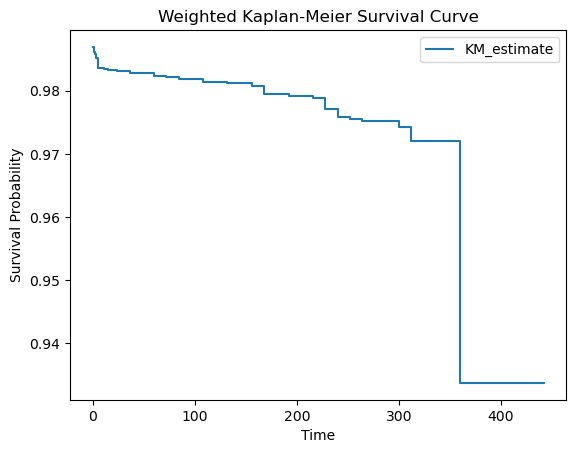

In [43]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="It looks like your weights are not integers"
)

import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

kmf.fit(
    durations=survival_attributes['duration'],
    event_observed=survival_attributes['event'],
    weights=weights   # your non-integer weights
)

kmf.plot(ci_show=False)  # recommended: hide biased CI)

plt.title("Weighted Kaplan-Meier Survival Curve")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.show()

Interpret as probability of not encountering child mortality.....

$$\begin{array}{|l|l|}
\hline
\textbf{Feature} & \textbf{Interpretation} \\
\hline
\text{Y-Axis Range} & \text{Survival remains very high (above 93\%); child mortality is rare in this sample.} \\
\hline
\text{Small "Steps"} & \text{Each small drop represents one or more deaths at that specific month.} \\
\hline
\text{Large Final Drop} & \text{Likely a small number of "at-risk" individuals left at the end of the study.} \\
\hline
\text{Horizontal Lines} & \text{Periods where no deaths were recorded (survival probability stayed constant).} \\
\hline
\end{array}$$

**Why the big drop at 360 months?**

The "staircase" gets steeper at the end not necessarily because more people are dying, but because the denominator (the number of children still being tracked) has become very small.

In survival analysis, if you only have 5 children left in the study at month 360 and one of them dies, the survival probability will plummet much faster than if one child died at month 10 when you had 8,000 children. This is a common "end-of-study" effect.

**A Quick Check on Your Time Scale**

The X-axis goes up to 440.

If this is in months, then there's tracking children up to roughly 36 years old.

If the research goal is Under-Five Mortality (U5MR), then to filter the data to only look at the first 60 months.

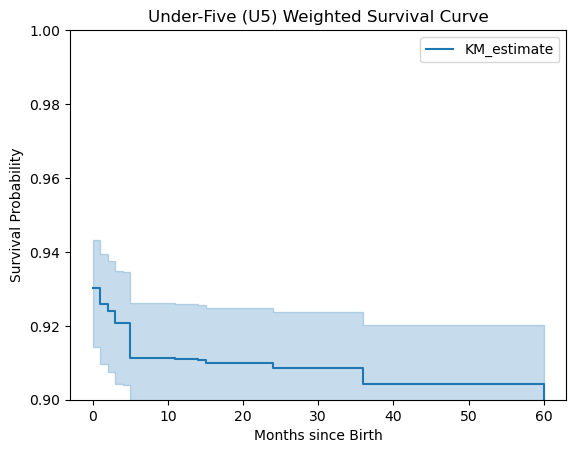

In [44]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="It looks like your weights are not integers"
)

# Filter for children followed up to 5 years (60 months)
df_u5 = survival_attributes[survival_attributes['duration'] <= 60].copy()

# Re-extract the weights for the filtered index
weights_u5 = survival_data.loc[df_u5.index, "wmweight"]


kmf = KaplanMeierFitter()

# Fit the model on the 0-60 month window
kmf.fit(
    durations=df_u5['duration'], 
    event_observed=df_u5['event'], 
    weights=weights_u5
)

# Plot with a focus on the Y-axis to see the detail
ax = kmf.plot_survival_function()
plt.title("Under-Five (U5) Weighted Survival Curve")
plt.xlabel("Months since Birth")
plt.ylabel("Survival Probability")
plt.ylim(0.90, 1.0) # Zooming the Y-axis to see small drops clearly
plt.show()



This "zoomed" plot is much more informative for public health analysis! It clearly shows that the highest risk period is the very beginning of life.

$$\begin{array}{|l|l|}
\hline
\textbf{Observation} & \textbf{Interpretation} \\
\hline
\text{Initial Drop (Months 0-1)} & \text{Neonatal mortality: The curve drops instantly from 1.0 to below 0.94.} \\
\hline
\text{Infancy (Months 1-12)} & \text{The curve continues to step down, reaching roughly 0.91 by the first year.} \\
\hline
\text{Childhood (Months 12-60)} & \text{The slope flattens significantly; survival stabilizes after the first year.} \\
\hline
\text{Confidence Band (Blue Shaded Area)} & \text{Shows the uncertainty (95\% CI). Note it widens as time increases.} \\
\hline
\end{array}$$


**Analysis of the Patterns:**

1. The "Steep Slope" (0–5 Months): Notice how much sharper the drops are in the first few months. This suggests that interventions (like vaccines, breastfeeding support, or neonatal care) would have the biggest impact here.

2. The Survival Plateau: After about month 36 (3 years), the curve is almost flat. This indicates that once a child in this sample reaches age 3, their probability of survival until age 5 is nearly 100%.

3. U5 Survival Rate: According to this graph, approximately 90.5% of children in this population survive to their 5th birthday. Conversely, the Under-Five Mortality Rate is roughly 95 per 1,000 live births.


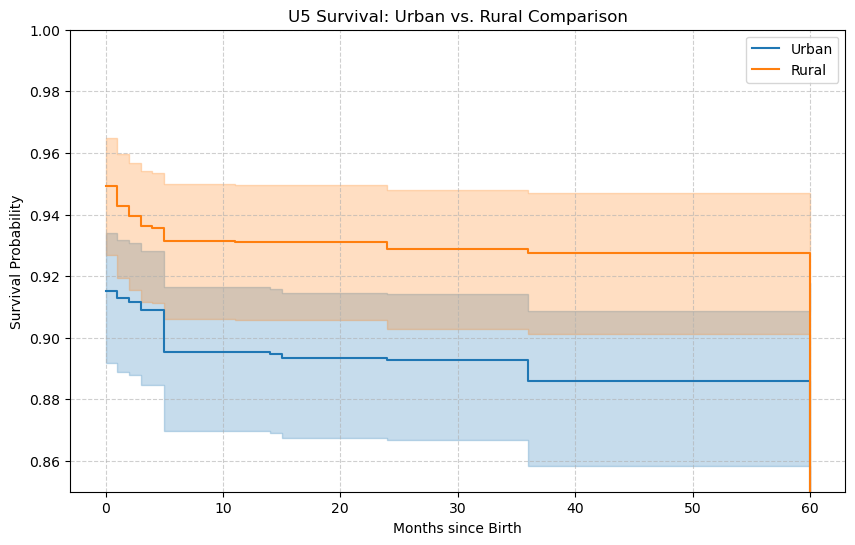

In [45]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# 1. Setup the plot
fig, ax = plt.subplots(figsize=(10, 6))
kmf_urban = KaplanMeierFitter()
kmf_rural = KaplanMeierFitter()

# 2. Filter data by Urban (HH6 == 1) and Rural (HH6 == 2)
urban_mask = (df_u5['HH6'] == 1)
rural_mask = (df_u5['HH6'] == 2)

# 3. Fit and Plot Urban
kmf_urban.fit(df_u5.loc[urban_mask, 'duration'], 
              event_observed=df_u5.loc[urban_mask, 'event'], 
              weights=survival_data.loc[df_u5.loc[urban_mask].index, "wmweight"], 
              label='Urban')
kmf_urban.plot_survival_function(ax=ax)

# 4. Fit and Plot Rural
kmf_rural.fit(df_u5.loc[rural_mask, 'duration'], 
              event_observed=df_u5.loc[rural_mask, 'event'], 
              weights=survival_data.loc[df_u5.loc[rural_mask].index, "wmweight"], 
              label='Rural')
kmf_rural.plot_survival_function(ax=ax)

# 5. Formatting
plt.title("U5 Survival: Urban vs. Rural Comparison")
plt.xlabel("Months since Birth")
plt.ylabel("Survival Probability")
plt.ylim(0.85, 1.0) # Adjust based on your previous plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Cox Model Development**

In [46]:
# Align by index: this ensures rows in survival_data matches rows in survival_attributes and adding 'wmweight.
survival_attributes['wmweight'] = survival_data.loc[survival_attributes.index, 'wmweight']

# Check if any rows are missing weights
missing_weights = survival_attributes['wmweight'].isna().sum()
print(f"Rows missing weights: {missing_weights}")

Rows missing weights: 0


In [47]:
from lifelines import CoxPHFitter

survival_attributes = survival_attributes.drop(columns=['age_group_death', 'age_group_death_int'])

cph = CoxPHFitter()

cph.fit(
    survival_attributes, 
    duration_col='duration', 
    event_col='event', 
    weights_col='wmweight',
    robust=True  
        # Using 'robust=True' handles the non-integer weight issue
        # Add this to fix the biased variance estimate
)

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 6492.21 total observations, 6358.47 right-censored observations>
             duration col = 'duration'
                event col = 'event'
              weights col = 'wmweight'
          robust variance = True
      baseline estimation = breslow
   number of observations = 6492.21
number of events observed = 133.732
   partial log-likelihood = -1109.05
         time fit was run = 2026-03-18 01:11:02 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
BH2        1.68      5.35      0.32            1.06            2.30                2.88                9.95
BH3       -0.09      0.91      0.23           -0.54            0.37                0.58                1.44
brthord    0.48      1.61      0.19            0.11            0.84                1.12                2.32
birthint  -0.08      0.92      0.09           -0.26            0.09                0.77                1.09
magebrt    0.05      1.05      0.27           -0.48            0.59                0.62                1.80
welevel   -0.19      0.82      0.15           -0.49            0.10                0.61                1.11
wscore    -0.13      0.88      0.10           -0.33            0.07                0.72                1.08
insurance -0.59      0.55      0.26           -1.11           -0.08                0.33                0.92
HH6       -0.47      0.63      0.27           -0.99            0.06                0.37                1.06
HH7        0.01      1.01      0.09           -0.18            0.19                0.84                1.21
ethnicity -0.26      0.77      0.13           -0.52           -0.01                0.60                0.99

           cmp to     z      p  -log2(p)
covariate                               
BH2          0.00  5.30 <0.005     23.00
BH3          0.00 -0.38   0.70      0.51
brthord      0.00  2.57   0.01      6.61
birthint     0.00 -0.94   0.35      1.52
magebrt      0.00  0.19   0.85      0.24
welevel      0.00 -1.27   0.20      2.30
wscore       0.00 -1.23   0.22      2.20
insurance    0.00 -2.26   0.02      5.40
HH6          0.00 -1.75   0.08      3.64
HH7          0.00  0.09   0.93      0.11
ethnicity    0.00 -2.02   0.04      4.51
---
Concordance = 0.62
Partial AIC = 2240.09
log-likelihood ratio test = 60.66 on 11 df
-log2(p) of ll-ratio test = 27.09

### Random Forest

To identify the most influential factors in child survival, to use a Random Forest Classifier to rank feature importance. Since Random Forest is a machine learning algorithm, it is excellent at capturing non-linear relationships (like the complex interaction between wealth, education, and health) that a standard Cox model might miss.

A Random Forest is an ensemble of $B$ independent decision trees (Breiman, 2001), where each tree is grown using a combination of Bagging (Bootstrap Aggregating) and Feature Randomness.

**The Ensemble Model:**

For a regression task, the Random Forest prediction $\hat{f}_{rf}^B(x)$ is the average of the predictions from all individual trees $T_b$:

$$\hat{f}_{rf}^B(x) = \frac{1}{B} \sum_{b=1}^{B} T_b(x, \Theta_b)$$

For classification, the model takes a **majority vote** of the predicted classes.

**The Individual Tree ($T_b$):**

Each tree is trained on a bootstrap sample $Z^*$ of the original training data. During the construction of each tree, at each node split:

A random subset of $m$ features is selected from the total $p$ features (typically $m \approx \sqrt{p}$).

The best split is found only among these $m$ features by minimizing an impurity measure, such as Gini Impurity for classification:

$$G = \sum_{k=1}^{K} \hat{p}_{mk}(1 - \hat{p}_{mk})$$

Or Mean Squared Error (MSE) for regression:

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

### Random Forest Feature Importance

Random Forest performs feature selection by ranking variables based on how much they contribute to the model's predictive power. The two primary metrics are:

**Mean Decrease in Impurity (MDI / Gini Importance)**

This calculates the total reduction in the loss function (Gini or MSE) brought by a specific feature, averaged over all trees in the forest.

$$VIM_j = \frac{1}{B} \sum_{b=1}^{B} \sum_{t \in T_b : v(s_t)=j} \Delta I(s_t, t)$$

$v(s_t)=j$ means feature $j$ was used for the split at node $t$.

$\Delta I$ is the weighted decrease in impurity from that split.

**Mean Decrease in Accuracy (MDA / Permutation Importance)**

This is often considered more robust. It measures the impact of a feature by randomly shuffling its values in the Out-of-Bag (OOB) samples and observing the drop in model accuracy.

$$Importance(X_j) = \text{Accuracy}_{base} - \text{Accuracy}_{permuted(X_j)}$$

If shuffling a feature's values significantly breaks the model's performance, that feature is deemed highly important.

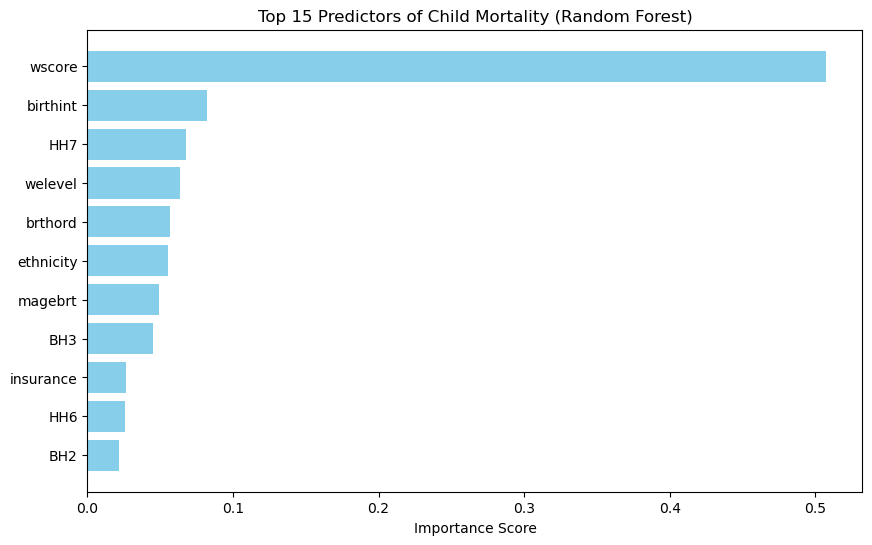

In [48]:
from sklearn.ensemble import RandomForestClassifier

# 1. Prepare Data
# We exclude the target ('event'), the time component ('duration'), and 'wmweight' from predictors
X = survival_attributes.drop(columns=['event', 'duration', 'wmweight'])
y = survival_attributes['event']

# Handle categorical variables (One-Hot Encoding if not already done)
X = pd.get_dummies(X, drop_first=True)

# 2. Random Forest Feature Importance
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X, y)

# Get importance scores
importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 3. Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:15], feature_importance_df['Importance'][:15], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Top 15 Predictors of Child Mortality (Random Forest)')
plt.gca().invert_yaxis()
plt.show()

**Random Forest (prediction power)**

1. wscore dominates (~0.51 importance) → massively more predictive than everything else

2. Then a second tier:

       birthint

       HH7

       welevel

       brthord

       ethnicity

This model is telling you:

    “If I want to predict child mortality, household/wealth-related factors and spacing matter most.”

**Cox Model (statistical significance & direction)**

Significant variables (p < 0.05):

    BH2 → strong positive effect (HR ≈ 5.35)

    brthord → increases risk (HR ≈ 1.61)

    insurance → reduces risk (HR ≈ 0.55)

    ethnicity → reduces risk (HR ≈ 0.77)

Borderline:

    HH6 (p ≈ 0.08)

Not significant:

    wscore (!!)

    birthint

    welevel

    HH7

    magebrt

**Why is wscore:**

🔝 #1 in Random Forest

❌ NOT significant in Cox?

This is a classic case of nonlinear + interaction effects:

**Random Forest:**

    Captures thresholds (e.g., poverty tipping points)

    Captures interactions (wealth × education × household size)

**Cox Proportional Hazards Model:**

    Assumes linear log-hazard relationship

    Misses nonlinear structure unless you explicitly model it

**Translation:**

    Wealth matters a lot, but not in a simple linear way.

**Strongest causal signals (from Cox)**

1. BH2 (HR ~ 5.35)

       → Huge risk increase

       → Likely a critical health/demographic indicator (needs careful interpretation)

2. brthord (birth order)

       → Higher order = higher mortality risk

       → Resource dilution / maternal depletion effect

3. insurance (HR ~ 0.55)

       → Protective effect

       → Access to healthcare matters

4. ethnicity (HR ~ 0.77)

       → Structural/social differences affecting outcomes


**Strong predictors (from Random Forest)**

1. wscore (wealth index)

       → Core socioeconomic driver

2. birthint (birth interval)

       → Spacing between births affects survival

3. welevel (education?)

       → Maternal education proxy

4. HH variables (HH6, HH7)

       → Household composition / crowding


**System likely has:**

Structural drivers (wealth, education, ethnicity)

Biological/demographic drivers (birth order, spacing)

Access factors (insurance)

But:

    The effects are nonlinear and interacting

    Which is why ML picks them up strongly, but Cox underestimates them

### Cox Model with Interaction Terms and Proportional Hazards Diagnostics (Schoenfeld Residuals)

In [49]:
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test

**Adding Interaction Terms:**

Incorporates:

1. wscore × welevel (wealth × education)

2. wscore × ethnicity

3. birthint × brthord

In [50]:
# Core interactions
survival_attributes["wscore_x_welevel"] = survival_attributes["wscore"] * survival_attributes["welevel"]
survival_attributes["wscore_x_ethnicity"] = survival_attributes["wscore"] * survival_attributes["ethnicity"]
survival_attributes["birthint_x_brthord"] = survival_attributes["birthint"] * survival_attributes["brthord"]

**Defining Model Features:**

In [51]:
features = [
    # Core variables
    "wscore", "birthint", "brthord", "magebrt",
    "welevel", "insurance", "HH6", "HH7",
    "ethnicity", "BH2", "BH3",
    
    # Interactions
    "wscore_x_welevel",
    "wscore_x_ethnicity",
    "birthint_x_brthord"
]

**Fitting the Cox Model:**

In [52]:
cph = CoxPHFitter(penalizer=0.01)  # helps with interaction stability

df_model = survival_attributes[features + ["duration", "event"]].copy()
df_model["wmweight"] = survival_data.loc[df_model.index, "wmweight"]

cph_inter = CoxPHFitter(penalizer=0.01)

cph_inter.fit(
    df_model,
    duration_col="duration",
    event_col="event",
    weights_col="wmweight",
    robust=True
)

cph_inter.print_summary()

model,lifelines.CoxPHFitter
duration col,'duration'
event col,'event'
weights col,'wmweight'
penalizer,0.01
l1 ratio,0.0
robust variance,True
baseline estimation,breslow
number of observations,6492.21
number of events observed,133.732
partial log-likelihood,-1118.77


**Testing Proportional Hazards Assumption Using Schoenfeld Residuals**

In [53]:
ph_test = proportional_hazard_test(cph_inter, df_model, time_transform='rank')
print(ph_test.summary)

                    test_statistic         p  -log2(p)
BH2                       0.263640  0.607630  0.718734
BH3                       1.205796  0.272166  1.877440
HH6                       2.349704  0.125307  2.996463
HH7                       5.059260  0.024495  5.351387
birthint                  2.112167  0.146132  2.774653
birthint_x_brthord        3.694238  0.054601  4.194936
brthord                   0.549668  0.458453  1.125153
ethnicity                 2.628947  0.104931  3.252483
insurance                 0.660433  0.416407  1.263933
magebrt                   0.018069  0.893071  0.163153
welevel                   0.337257  0.561417  0.832856
wscore                    8.093864  0.004442  7.814725
wscore_x_ethnicity        0.570463  0.450075  1.151763
wscore_x_welevel          4.122882  0.042307  4.562962


<h1>Proportional Hazards Diagnostics & Fix</h1>

<h2>1. What Failed the PH Assumption?</h2>
<p>Using Schoenfeld residual tests:</p>

<h3 style="color:red;">Clear violations (p &lt; 0.05)</h3>
<ul>
  <li><strong>wscore</strong> (p = 0.0044) → strong violation</li>
  <li><strong>HH7</strong> (p = 0.0245) → violation</li>
  <li><strong>wscore × welevel</strong> (p = 0.0423) → violation</li>
</ul>

<h3 style="color:orange;">Borderline</h3>
<ul>
  <li>birthint × brthord (p ≈ 0.055)</li>
</ul>

<h3 style="color:green;">No issues</h3>
<ul>
  <li>insurance</li>
  <li>brthord</li>
  <li>ethnicity</li>
  <li>magebrt</li>
  <li>welevel</li>
  <li>BH2, BH3</li>
</ul>

<hr>

<h2>2. What This Means</h2>

<p>The Cox Proportional Hazards model assumes:</p>
<blockquote>
  Effects are constant over time
</blockquote>

<p>Results show that this assumption is violated for key variables.</p>

<h3>Variables with time-varying effects:</h3>
<ul>
  <li><strong>wscore</strong> (wealth)</li>
  <li><strong>HH7</strong> (household structure)</li>
  <li><strong>wscore × welevel</strong> (wealth × education interaction)</li>
</ul>

<hr>

**Resolution: Treat the Time-Varying Effects**

Will end this development here....for now

## Closing Remarks 

Arguably the most essential part of data science is data wrangling. Such task in this development is deemed highly sucessful, since stochastic/statistical models became relevant. More interest and practice with survey data is required for substantial development. 

## References

Breiman, L. (2001). Random forests. **Machine Learning**, 45(1), 5–32. 

Collett, D. (2014). Modelling Survival Data in Medical Research (3rd ed.). *Chapman & Hall/CRC*.

Cox, D. R. (1972). Regression Models and Life-Tables. *Journal of the Royal Statistical Society: Series B (Methodological)*, 34(2), 187–202. 

Hosmer, D. W., Lemeshow, S., & May, S. (2008). Applied Survival Analysis: Regression Modelling of Time-To-Event Data (2nd ed.). *Wiley-Interscience*.

Kaplan, E. L., & Meier, P. (1958). Nonparametric Estimation from Incomplete Observations. *Journal of the American Statistical Association*, 53(282), 457–481.

UNICEF. (n.d.). UNICEF MICS. https://mics.unicef.org/ 

UNICEF. (n.d.-b). Surveys | UNICEF MICS. https://mics.unicef.org/surveys 